## Лабораторная работа 8


№1 (3 балла)
Выполните задания из файла https://cloud.mail.ru/public/DGCu/Kw2Q4xGwd. Данные можно
взять здесь https://cloud.mail.ru/public/CiBD/PEaCv9DyD.

### Важность признаков


1. Загрузите выборку из файла titanic.csv с помощью пакета Pandas.

In [2]:
import pandas as pd

df = pd.read_csv('titanic.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


2. Оставьте в выборке четыре признака: класс пассажира (Pclass), цену билета (Fare), возраст пассажира (Age) и его пол (Sex).

In [213]:
filtered_df = df[['Pclass', 'Fare', 'Age', 'Sex', 'Survived']]
filtered_df

,Pclass,Fare,Age,Sex,Survived
0,3,7.2500,22.0,male,0
1,1,71.2833,38.0,female,1
2,3,7.9250,26.0,female,1
3,1,53.1000,35.0,female,1
4,3,8.0500,35.0,male,0
...,...,...,...,...,...
886,2,13.0000,27.0,male,0
887,1,30.0000,19.0,female,1
888,3,23.4500,NaN,female,0
889,1,30.0000,26.0,male,1


3. Обратите внимание, что признак Sex имеет строковые значения

In [214]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Fare      891 non-null    float64
 2   Age       714 non-null    float64
 3   Sex       891 non-null    object 
 4   Survived  891 non-null    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 34.9+ KB


In [215]:
filtered_df = pd.get_dummies(filtered_df, columns=['Sex'], drop_first=True)

In [216]:
filtered_df

,Pclass,Fare,Age,Survived,Sex_male
0,3,7.2500,22.0,0,True
1,1,71.2833,38.0,1,False
2,3,7.9250,26.0,1,False
3,1,53.1000,35.0,1,False
4,3,8.0500,35.0,0,True
...,...,...,...,...,...
886,2,13.0000,27.0,0,True
887,1,30.0000,19.0,1,False
888,3,23.4500,NaN,0,False
889,1,30.0000,26.0,1,True


4. Выделите целевую переменную — она записана в столбце Survived

In [217]:
target = filtered_df['Survived']
target

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

5. В данных есть пропущенные значения — например, для некоторых
пассажиров неизвестен их возраст. Такие записи при чтении их в
pandas принимают значение nan. Найдите все объекты, у которых
есть пропущенные признаки, и удалите их из выборки.


In [218]:
filtered_df.isna().sum()

Pclass        0
Fare          0
Age         177
Survived      0
Sex_male      0
dtype: int64

In [219]:
filtered_df = filtered_df.dropna()
filtered_df

,Pclass,Fare,Age,Survived,Sex_male
0,3,7.2500,22.0,0,True
1,1,71.2833,38.0,1,False
2,3,7.9250,26.0,1,False
3,1,53.1000,35.0,1,False
4,3,8.0500,35.0,0,True
...,...,...,...,...,...
885,3,29.1250,39.0,0,False
886,2,13.0000,27.0,0,True
887,1,30.0000,19.0,1,False
889,1,30.0000,26.0,1,True


In [220]:
target = filtered_df['Survived']
target

0      0
1      1
2      1
3      1
4      0
      ..
885    0
886    0
887    1
889    1
890    0
Name: Survived, Length: 714, dtype: int64

In [221]:
filtered_df.isna().sum()
filtered_df = filtered_df.drop(columns=['Survived'])

6. Обучите решающее дерево с параметром random_state=241 и остальными параметрами по умолчанию.


In [222]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X = filtered_df
y = target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
clf = DecisionTreeClassifier(random_state=241)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели: {accuracy:.4f}")

Точность модели: 0.7256


7. Вычислите важности признаков и найдите два признака с наибольшей важностью. Их названия будут ответами для данной задачи
(в качестве ответа укажите названия признаков через запятую без
пробелов).

In [223]:
filtered_df.shape

(714, 4)

In [224]:
target.shape

(714,)

In [227]:
importances = pd.Series(clf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)

Sex_male    0.320951
Age         0.282899
Fare        0.265846
Pclass      0.130305
dtype: float64

№2 (3 балла)
Построить дерево решений, определяющее наличие сахарного диабета у женщин. Данные
возьмите отсюда https://cloud.mail.ru/public/XD8U/pgDYnHrjY.

Данные содержат следующие характеристики:
1. Pregnancies – число случаев беременности
2. Glucose – концентрация глюкозы в крови
3. BloodPressure – артериальное диастолическое давление (мм рт. ст.)
4. SkinThickness – толщина кожной складки трехглавой мышцы (мм)
5. Insulin – 2-х часовой сывороточный инсулин
6. BMI – индекс массы тела
7. DiabetesPedigreeFunction – числовой параметр наследственности диабета
8. Age – возраст
Outcome – целевая переменная: 1 – наличие заболевания, 0 – отсутствие

1. Загрузите данные в DataFrame с помощью функции read_csv библиотеки pandas.


In [258]:
df = pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Unnamed: 9
0,6,148,72,35,0,"33,6","0,627",50,1,NaN
1,1,85,66,29,0,"26,6","0,351",31,0,NaN
2,8,183,64,0,0,"23,3","0,672",32,1,NaN
3,1,89,66,23,94,"28,1","0,167",21,0,NaN
4,0,137,40,35,168,"43,1","2,288",33,1,NaN
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,"32,9","0,171",63,0,NaN
764,2,122,70,27,0,"36,8","0,34",27,0,NaN
765,5,121,72,23,112,"26,2","0,245",30,0,NaN
766,1,126,60,0,0,"30,1","0,349",47,1,NaN


In [259]:
df.isna().sum()

Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
Unnamed: 9                  768
dtype: int64

In [260]:
df = df.dropna(axis=1)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,"33,6","0,627",50,1
1,1,85,66,29,0,"26,6","0,351",31,0
2,8,183,64,0,0,"23,3","0,672",32,1
3,1,89,66,23,94,"28,1","0,167",21,0
4,0,137,40,35,168,"43,1","2,288",33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,"32,9","0,171",63,0
764,2,122,70,27,0,"36,8","0,34",27,0
765,5,121,72,23,112,"26,2","0,245",30,0
766,1,126,60,0,0,"30,1","0,349",47,1


In [261]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [262]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Pregnancies               768 non-null    int64 
 1   Glucose                   768 non-null    int64 
 2   BloodPressure             768 non-null    int64 
 3   SkinThickness             768 non-null    int64 
 4   Insulin                   768 non-null    int64 
 5   BMI                       768 non-null    object
 6   DiabetesPedigreeFunction  768 non-null    object
 7   Age                       768 non-null    int64 
 8   Outcome                   768 non-null    int64 
dtypes: int64(7), object(2)
memory usage: 54.1+ KB


In [263]:
df['BMI'] = df['BMI'].str.replace(',', '.').astype(float)
df['DiabetesPedigreeFunction'] = df['DiabetesPedigreeFunction'].str.replace(',', '.').astype(float)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


C:\Users\lidiya\AppData\Local\Temp\ipykernel_3956\806060780.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['BMI'] = df['BMI'].str.replace(',', '.').astype(float)
C:\Users\lidiya\AppData\Local\Temp\ipykernel_3956\806060780.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['DiabetesPedigreeFunction'] = df['DiabetesPedigreeFunction'].str.replace(',', '.').astype(float)


2. Разделите данные на обучающую и тестовую выборки с помощью функции
train_test_split.

In [277]:
X = df.drop(columns = 'Outcome')
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=241)

3. Постройте дерево решений с помощью класса DecisionTreeClassifier.

In [278]:
clf = DecisionTreeClassifier(random_state=241)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

4. Оцените качество модели с помощью функции classification_report.


In [281]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.76      0.75       138
           1       0.62      0.59      0.61        93

    accuracy                           0.69       231
   macro avg       0.68      0.68      0.68       231
weighted avg       0.69      0.69      0.69       231



5. Подберите оптимальное значение гиперпараметра max_depth с помощью поиска по
сетке (класс GridSearchCV).

In [286]:
from sklearn.model_selection import GridSearchCV

parameters = {'max_depth':[2, 5, 10, 20, 100, 1000]}
dtc = DecisionTreeClassifier()
grid = GridSearchCV(dtc, parameters)
grid.fit(X_train, y_train)

# Вывод лучших параметров и результатов
print(f"Лучшие параметры: {grid.best_params_}")
print(f"Лучшая точность при кросс-валидации: {grid.best_score_:.4f}")

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test,y_pred_best))

Лучшие параметры: {'max_depth': 2}
Лучшая точность при кросс-валидации: 0.7560
              precision    recall  f1-score   support

           0       0.73      0.86      0.79       138
           1       0.71      0.54      0.61        93

    accuracy                           0.73       231
   macro avg       0.72      0.70      0.70       231
weighted avg       0.73      0.73      0.72       231



№3 (3 балла)
Выполните задания из файла https://cloud.mail.ru/public/2Btw/56cT2htNd. Данные можно
взять здесь https://cloud.mail.ru/public/mMAE/P3SZLgJWQ.

### Практическое задание №1.6.6


Для выполнения практического задания будем использовать файл
«winequality-red.csv», содержащий результаты физико-химических тестов
красного вина.
Источник: https://www.kaggle.com/uciml/red-wine-quality-cortez-et-al-2009.

Задача: построить модель случайного леса, определяющую хорошее вино
или плохое на основе результатов физико-химических тестов.
Входные переменные (признаки):
* • fixed acidity – фиксированная кислотность
* • volatile acidity – летучая кислотность
* • citric acid – содержание лимонной кислоты
* • residual sugar – остаточный сахар
* • chlorides – хлориды
* • free sulfur dioxide – свободный диоксид серы
* • total sulfur dioxide – общий диоксид серы
* • density – плотность
* • pH
* • sulphates – сульфаты
* • alcohol – спирт

Целевая переменная – quality (качество): 0 – плохое вино, 1 – хорошее вино.

1. Загрузите набор данных из файла «winequality-red.csv» в DataFrame.

In [314]:
df = pd.read_csv('winequality-red.csv' , decimal=",")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
 12  Unnamed: 12           0 non-null      float64
dtypes: float64(12), int64(1)
memory usage: 162.5 KB


2. Обучите модель случайного леса (RandomForestClassifier).


In [315]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = df.drop(columns = 'quality')
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=241)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)


3. Оцените качество модели. Метрики для оценки качества выберите
самостоятельно.

In [316]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8145833333333333
              precision    recall  f1-score   support

           0       0.80      0.81      0.80       225
           1       0.83      0.82      0.82       255

    accuracy                           0.81       480
   macro avg       0.81      0.81      0.81       480
weighted avg       0.81      0.81      0.81       480



4. Оцените информативность признаков с помощью атрибута
feature_importances_.

In [317]:
importances = pd.Series(clf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)

alcohol                 0.172239
sulphates               0.133378
volatile acidity        0.114757
total sulfur dioxide    0.100956
density                 0.083510
chlorides               0.075747
fixed acidity           0.073571
pH                      0.066742
citric acid             0.061318
free sulfur dioxide     0.061048
residual sugar          0.056734
Unnamed: 12             0.000000
dtype: float64

4. Поимпровизируйте с этими данными. Попробуйте построить другие модели
(на ваш выбор). Также, можно попробовать изменить значения
гиперпараметров моделей и посмотреть, как изменится результат.

In [320]:
param_grid = {
    'n_estimators': [100, 200, 300],          # количество деревьев
    'max_depth': [None, 10, 20, 30],          # глубина
    'min_samples_split': [2, 5, 10],          # минимум для сплита
    'min_samples_leaf': [1, 2, 4],            # минимум объектов в листе
    'max_features': ['sqrt', 'log2', None],   # выбор признаков
    'bootstrap': [True, False]                # бутстрап выборки
}

# Поиск лучших параметров
grid_search = GridSearchCV(
estimator=clf,
param_grid=param_grid,
cv=5,
scoring='accuracy',
n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

best_clf = grid_search.best_estimator_

y_pred = grid_search.best_estimator_.predict(X_test)
print("\nClassification report:\n", classification_report(y_test, y_pred))


{'bootstrap': True, 'max_depth': 30, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Classification report:
               precision    recall  f1-score   support

           0       0.80      0.83      0.82       225
           1       0.85      0.82      0.83       255

    accuracy                           0.82       480
   macro avg       0.82      0.83      0.82       480
weighted avg       0.83      0.82      0.83       480



In [303]:
clf = DecisionTreeClassifier(random_state=241)
clf.fit(X_train, y_train)

y_pred_dt = clf.predict(X_test)
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.75      0.71      0.73       225
           1       0.75      0.80      0.77       255

    accuracy                           0.75       480
   macro avg       0.75      0.75      0.75       480
weighted avg       0.75      0.75      0.75       480



У дерева решений точность меньше(0.75), чем у случайного леса(0.82)

№4 (3 балла)
Выполните задания из файла https://cloud.mail.ru/public/nbue/PCozBiM4f. Данные можно
взять здесь https://cloud.mail.ru/public/ysqp/AuPY2gpwo.

#### Размер случайного леса


1. Загрузите данные из файла abalone.csv. Это датасет, в котором требуется предсказать возраст ракушки (число колец) по физическим
измерениям.

In [337]:
df = pd.read_csv('abalone_csv.csv', decimal=',')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sex                    4177 non-null   object 
 1   Length                 4177 non-null   float64
 2   Diameter               4177 non-null   float64
 3   Height                 4177 non-null   float64
 4   Whole_weight           4177 non-null   float64
 5   Shucked_weight         4177 non-null   float64
 6   Viscera_weight         4177 non-null   float64
 7   Shell_weight           4177 non-null   float64
 8   Class_number_of_rings  4177 non-null   int64  
 9   Unnamed: 9             0 non-null      float64
 10  Unnamed: 10            0 non-null      float64
dtypes: float64(9), int64(1), object(1)
memory usage: 359.1+ KB


2. Преобразуйте признак Sex в числовой: значение F должно перейти
в -1, I — в 0, M — в 1. Если вы используете Pandas, то подойдет следующий код: data[’Sex’] = data[’Sex’].map(lambda x: 1 if x ==
’M’ else (-1 if x == ’F’ else 0))


In [338]:
df['Sex'] = df['Sex'].map(lambda x: 1 if x == 'M' else (-1 if x == 'F' else 0))
df

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Class_number_of_rings,Unnamed: 9,Unnamed: 10
0,1,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15,NaN,NaN
1,1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7,NaN,NaN
2,-1,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9,NaN,NaN
3,1,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10,NaN,NaN
4,0,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
4172,-1,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11,NaN,NaN
4173,1,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10,NaN,NaN
4174,1,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9,NaN,NaN
4175,-1,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10,NaN,NaN


3. Разделите содержимое файлов на признаки и целевую переменную.
В последнем столбце записана целевая переменная, в остальных —
признаки.

In [339]:
X = df.drop(columns='Class_number_of_rings')
y = df['Class_number_of_rings']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=241)


4. Обучите случайный лес (sklearn.ensemble.RandomForestRegressor)
с различным числом деревьев: от 1 до 50 (random_state=1). Для
каждого из вариантов оцените качество работы полученного леса
на кросс-валидации по 5 блокам. Используйте параметры
"random_state=1"и "shuffle=True"при создании генератора кроссвалидации sklearn.cross_validation.KFold. В качестве меры качества
воспользуйтесь коэффициентом детерминации (sklearn.metrics.r2_score).

In [342]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score

for i in range(1, 51):
    rfr = RandomForestRegressor(n_estimators=i, random_state=1)
    kf = KFold(n_splits=5, random_state=1, shuffle=True)
    cv_scores = cross_val_score(rfr, X, y, cv=kf, scoring='r2')
    mean_score = cv_scores.mean()
    print(f"Trees: {i}, Mean R2: {mean_score:.4f}")



Trees: 1, Mean R2: 0.1211
Trees: 2, Mean R2: 0.3430
Trees: 3, Mean R2: 0.4015
Trees: 4, Mean R2: 0.4432
Trees: 5, Mean R2: 0.4645
Trees: 6, Mean R2: 0.4717
Trees: 7, Mean R2: 0.4782
Trees: 8, Mean R2: 0.4827
Trees: 9, Mean R2: 0.4881
Trees: 10, Mean R2: 0.4950
Trees: 11, Mean R2: 0.4960
Trees: 12, Mean R2: 0.5017
Trees: 13, Mean R2: 0.5061
Trees: 14, Mean R2: 0.5099
Trees: 15, Mean R2: 0.5116
Trees: 16, Mean R2: 0.5137
Trees: 17, Mean R2: 0.5155
Trees: 18, Mean R2: 0.5169
Trees: 19, Mean R2: 0.5198
Trees: 20, Mean R2: 0.5195
Trees: 21, Mean R2: 0.5209
Trees: 22, Mean R2: 0.5212
Trees: 23, Mean R2: 0.5225
Trees: 24, Mean R2: 0.5237
Trees: 25, Mean R2: 0.5234
Trees: 26, Mean R2: 0.5249
Trees: 27, Mean R2: 0.5258
Trees: 28, Mean R2: 0.5273
Trees: 29, Mean R2: 0.5282
Trees: 30, Mean R2: 0.5288
Trees: 31, Mean R2: 0.5292
Trees: 32, Mean R2: 0.5297
Trees: 33, Mean R2: 0.5311
Trees: 34, Mean R2: 0.5306
Trees: 35, Mean R2: 0.5306
Trees: 36, Mean R2: 0.5307
Trees: 37, Mean R2: 0.5302
Trees: 38,

5. Определите, при каком минимальном количестве деревьев случайный лес показывает качество на кросс-валидации выше 0.52. Это
количество и будет ответом на задание.

Trees: 21, Mean R2: 0.5209

6. Обратите внимание на изменение качества по мере роста числа деревьев. Ухудшается ли оно?

* от 1 до 15 деревьев качество заметно растёт
* дальше каждое дерево даёт маленькое улучшение
* после 30 деревьев улучшения почти нет (плато)
* ни на одном шаге качество не ухудшается, максимум небольшие колебания на уровне ±0.001 — это статистический шум кросс-валидации.

№5 (3 балла)
Выполните задания из файла https://cloud.mail.ru/public/YQ1s/9LJK7ZWuT. Данные можно
взять здесь https://cloud.mail.ru/public/RE1b/eRFQujUhe.

#### Градиентный бустинг над решающими деревьями

1. Загрузите выборку из файла gbm-data.csv с помощью pandas и преобразуйте ее в массив numpy (параметр values у датафрейма). В
первой колонке файла с данными записано, была или нет реакция.
Все остальные колонки (d1 - d1776) содержат различные характеристики молекулы, такие как размер, форма и т.д. Разбейте выборку
на обучающую и тестовую, используя функцию train_test_split с
параметрами test_size = 0.8 и random_state = 241.

In [9]:
df = pd.read_csv('gbm-data.csv')
data = df.values

y = data[:, 0]
X = data[:, 1:]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=241)

2. Обучите GradientBoostingClassifier с параметрами n_estimators=250,
verbose=True, random_state=241 и для каждого значения learning_rate
из списка [1, 0.5, 0.3, 0.2, 0.1] проделайте следующее:


* Используйте метод staged_decision_function для предсказания качества на обучающей и тестовой выборке на каждой
итерации.
* Преобразуйте полученное предсказание по формуле 1
1+e
−y_pred ,
где y_pred — предсказанное значение.
* Вычислите и постройте график значений log-loss на обучающей и тестовой выборках, а также найдите минимальное значение метрики и номер итерации, на которой оно достигается

      Iter       Train Loss   Remaining Time 
         1           1.0190           30.16s
         2           0.9192           29.59s
         3           0.8272           29.91s
         4           0.7834           29.75s
         5           0.7109           29.39s
         6           0.6368           28.82s
         7           0.5797           29.81s
         8           0.5610           29.47s
         9           0.5185           29.24s
        10           0.4984           29.00s
        20           0.1999           27.31s
        30           0.1313           26.62s
        40           0.0790           25.28s
        50           0.0511           24.01s
        60           0.0352           22.83s
        70           0.0245           21.50s
        80           0.0162           20.32s
        90           0.0114           19.05s
       100           0.0077           17.85s
       200           0.0002            5.86s
Минимальный log-loss на test = 0.5823
Номер итерации: 

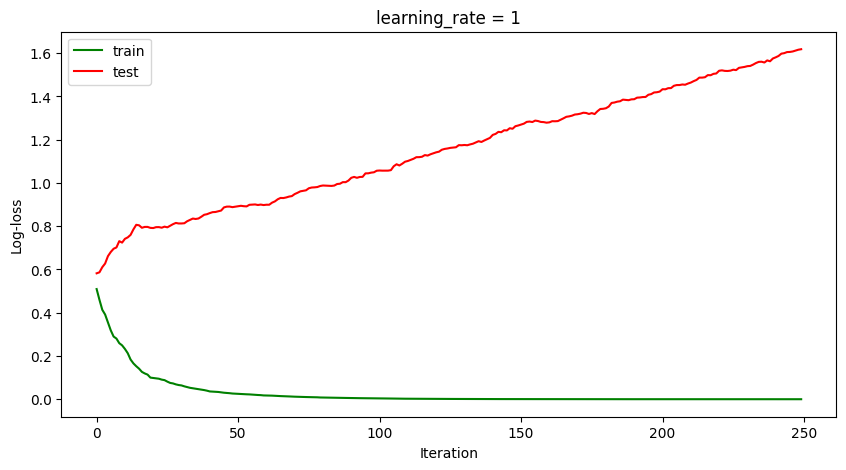

      Iter       Train Loss   Remaining Time 
         1           1.1255           33.04s
         2           1.0035           34.00s
         3           0.9386           33.00s
         4           0.8844           32.09s
         5           0.8381           31.93s
         6           0.7995           31.25s
         7           0.7559           30.53s
         8           0.7205           30.13s
         9           0.6958           29.96s
        10           0.6725           30.00s
        20           0.4672           28.57s
        30           0.3179           27.02s
        40           0.2274           25.53s
        50           0.1774           24.17s
        60           0.1394           22.80s
        70           0.1050           21.58s
        80           0.0805           20.37s
        90           0.0650           19.17s
       100           0.0511           17.97s
       200           0.0058            6.21s
Минимальный log-loss на test = 0.5585
Номер итерации: 

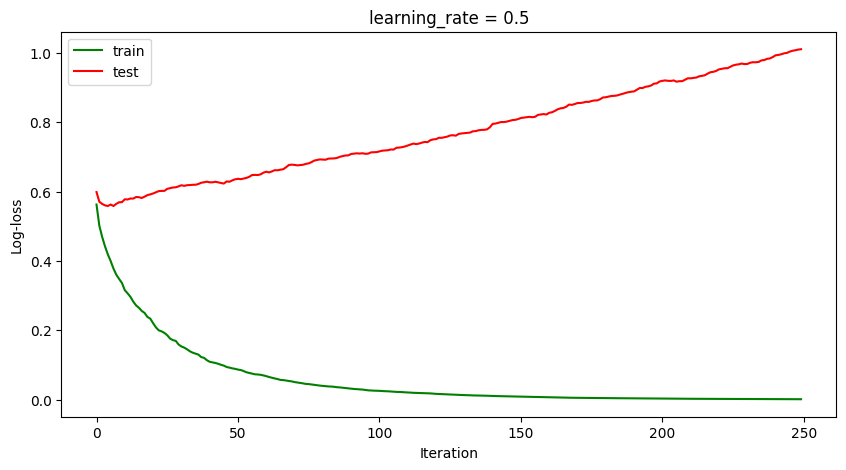

      Iter       Train Loss   Remaining Time 
         1           1.2095           30.10s
         2           1.1006           29.70s
         3           1.0240           28.98s
         4           0.9729           28.52s
         5           0.9387           28.19s
         6           0.8948           29.09s
         7           0.8621           28.92s
         8           0.8360           29.20s
         9           0.8171           29.29s
        10           0.7883           29.94s
        20           0.6164           29.94s
        30           0.4933           28.08s
        40           0.4248           26.33s
        50           0.3345           24.76s
        60           0.2760           23.81s
        70           0.2263           23.79s
        80           0.1971           22.97s
        90           0.1693           21.73s
       100           0.1388           20.35s
       200           0.0294            6.50s
Минимальный log-loss на test = 0.5426
Номер итерации: 

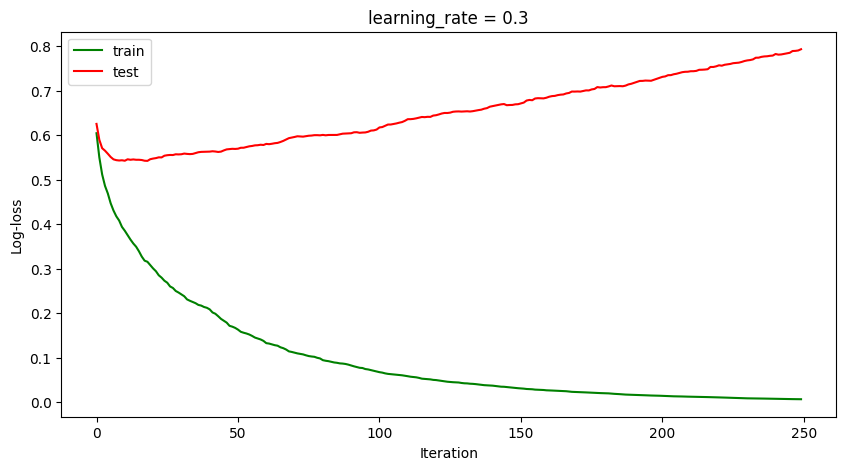

      Iter       Train Loss   Remaining Time 
         1           1.2613           30.86s
         2           1.1715           30.64s
         3           1.1009           31.21s
         4           1.0529           34.45s
         5           1.0130           33.08s
         6           0.9740           32.38s
         7           0.9475           32.23s
         8           0.9197           31.78s
         9           0.8979           31.41s
        10           0.8730           31.14s
        20           0.7207           29.56s
        30           0.6055           28.14s
        40           0.5244           27.76s
        50           0.4501           26.50s
        60           0.3908           25.31s
        70           0.3372           24.29s
        80           0.3009           22.82s
        90           0.2603           21.49s
       100           0.2327           20.14s
       200           0.0835            6.35s
Минимальный log-loss на test = 0.5305
Номер итерации: 

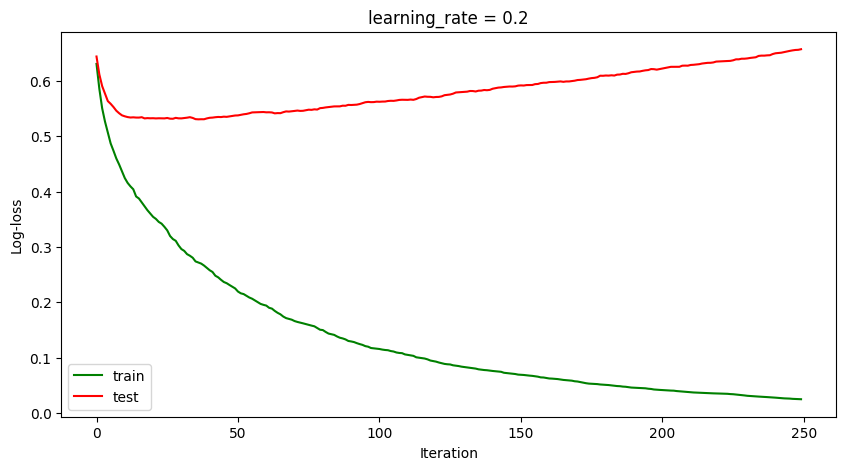

      Iter       Train Loss   Remaining Time 
         1           1.3199           30.91s
         2           1.2645           29.46s
         3           1.2170           29.66s
         4           1.1775           29.21s
         5           1.1404           29.42s
         6           1.1106           28.82s
         7           1.0844           28.61s
         8           1.0617           28.72s
         9           1.0411           28.90s
        10           1.0223           28.56s
        20           0.8864           26.98s
        30           0.7844           25.62s
        40           0.7176           24.52s
        50           0.6590           23.30s
        60           0.6120           22.03s
        70           0.5599           20.77s
        80           0.5242           19.60s
        90           0.4829           18.52s
       100           0.4473           17.79s
       200           0.2379            7.01s
Минимальный log-loss на test = 0.5261
Номер итерации: 

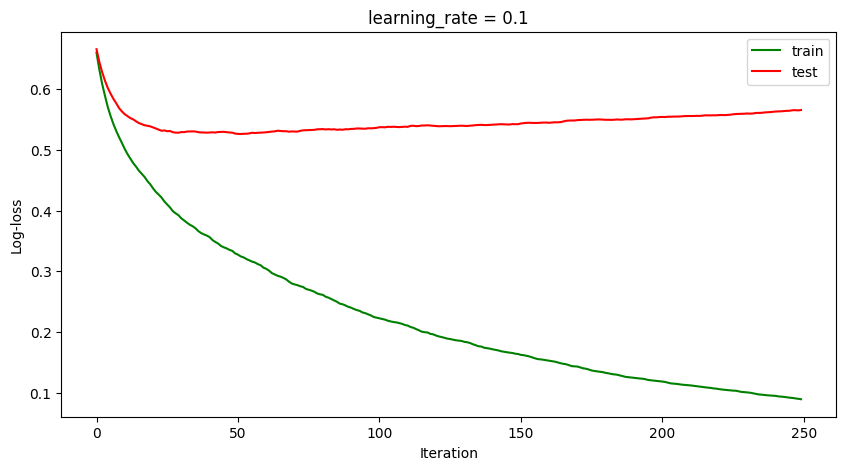

In [10]:
from matplotlib import pyplot as plt
import numpy as np
from sklearn.metrics import log_loss
from sklearn.ensemble import GradientBoostingClassifier

learning_rates = [1, 0.5, 0.3, 0.2, 0.1]
for lr in learning_rates:
    clf = GradientBoostingClassifier(
        n_estimators=250,
        verbose=True,
        random_state=241,
        learning_rate=lr
    )

    clf.fit(X_train, y_train)

    # Списки ошибок
    train_losses = []
    test_losses = []

    # Пробегаем по итерациям (staged_decision_function)
    for y_pred_train in clf.staged_decision_function(X_train):
        y_pred_train_prob = 1.0 / (1.0 + np.exp(-y_pred_train))
        train_losses.append(log_loss(y_train, y_pred_train_prob))

    for y_pred_test in clf.staged_decision_function(X_test):
        y_pred_test_prob = 1.0 / (1.0 + np.exp(-y_pred_test))
        test_losses.append(log_loss(y_test, y_pred_test_prob))

    # Находим минимальный log-loss
    min_test_loss = np.min(test_losses)
    best_iter = np.argmin(test_losses)

    print(f"Минимальный log-loss на test = {min_test_loss:.4f}")
    print(f"Номер итерации: {best_iter}")

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, "g-", label="train")
    plt.plot(test_losses, "r-", label="test")
    plt.title(f"learning_rate = {lr}")
    plt.xlabel("Iteration")
    plt.ylabel("Log-loss")
    plt.legend()
    plt.show()

3. Как можно охарактеризовать график качества на тестовой выборке, начиная с некоторой итерации: переобучение (overfitting) или
недообучение (underfitting)? В ответе укажите одно из слов overfitting
либо underfitting.

overfitting

4. Приведите минимальное значение log-loss на тестовой выборке и
номер итерации, на котором оно достигается, при learning_rate =
0.2.


Минимальный log-loss на test = 0.5305
Номер итерации: 36

5. На этих же данных обучите RandomForestClassifier с количеством
деревьев, равным количеству итераций, на котором достигается
наилучшее качество у градиентного бустинга из предыдущего пункта, random_state=241 и остальными параметрами по умолчанию.
Какое значение log-loss на тесте получается у этого случайного леса? (Не забывайте, что предсказания нужно получать с помощью
функции predict_proba. В данном случае брать сигмоиду от оценки
вероятности класса не нужно)

In [12]:
min_test_loss = np.min(test_losses)
best_iter = np.argmin(test_losses)
print(best_iter)

51


In [16]:
from sklearn.ensemble import RandomForestClassifier
rfc =  RandomForestClassifier(n_estimators=best_iter, random_state=241)
rfc.fit(X_train, y_train)
y_pred = rfc.predict_proba(X_test)
rf_logloss = log_loss(y_test, y_pred[:, 1])
print("Log-loss случайного леса:", rf_logloss)


Log-loss случайного леса: 0.5390618347947492


Обратите внимание, что, хотя в градиентного бустинге гораздо более слабые базовые алгоритмы, он выигрывает у случайного леса благодаря более "направленной"настройке — каждый следующий алгоритм
исправляет ошибки имеющейся композиции. Также он обучается быстрее случайного леса благодаря использованию неглубоких деревьев. В
то же время, случайный лес может показать более высокое качество при
неограниченных ресурсах — так, он выиграет у градиентного бустинга
на наших данных, если увеличить число деревьев до нескольких сотен
(проверьте сами!).
